In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
V = pd.read_csv('Remodeler_Landscape.csv', header=0, delimiter=',')

## Problem 4a — Nucleosome Metropolis-Hastings MCMC

N_valley = 50, N_barrier = 50
Barrier positions: 0.5 to 49.5
Barrier always > valley check: True


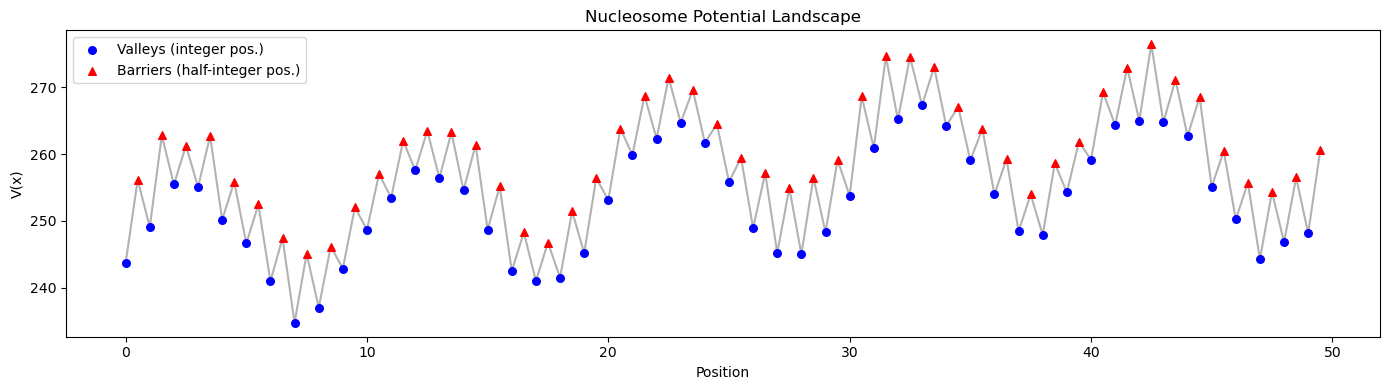

Number of valley positions: 50
V range: [234.8, 267.3]
Minimum V at position 7: V = 234.75


In [18]:
# Extract integer (valley) and half-integer (barrier) positions
positions = V['Position'].values
potentials = V['Potential'].values

mask_int = np.isclose(positions % 1, 0)
valley_pos = positions[mask_int].astype(int)
valley_V = potentials[mask_int]

mask_half = np.isclose(positions % 1, 0.5)
barrier_pos = positions[mask_half]
barrier_V_raw = potentials[mask_half]

N = len(valley_pos)  # Number of nucleosome positions
print(f"N_valley = {N}, N_barrier = {len(barrier_V_raw)}")
print(f"Barrier positions: {barrier_pos[0]:.1f} to {barrier_pos[-1]:.1f}")

# barrier_right[x] = V at the barrier when moving right from valley x to valley (x+1)%N
# Barrier at 0.5 is between valley 0 and valley 1 → barrier_right[0]
# Barrier at 49.5 is between valley 49 and valley 0 → barrier_right[49]
# Since barrier_pos goes 0.5, 1.5, ..., 49.5, each barrier_V_raw[k] is at position k+0.5
# So barrier_right[k] = barrier_V_raw[k] for k=0..49
barrier_right = barrier_V_raw.copy()

print(f"Barrier always > valley check: {np.all(barrier_right > valley_V)}")

# Plot the potential landscape
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(positions, potentials, 'k-', alpha=0.3)
ax.scatter(valley_pos, valley_V, c='blue', s=30, zorder=5, label='Valleys (integer pos.)')
ax.scatter(barrier_pos, barrier_V_raw, c='red', marker='^', s=30, zorder=5, label='Barriers (half-integer pos.)')
ax.set_xlabel('Position')
ax.set_ylabel('V(x)')
ax.set_title('Nucleosome Potential Landscape')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Number of valley positions: {N}")
print(f"V range: [{valley_V.min():.1f}, {valley_V.max():.1f}]")
print(f"Minimum V at position {valley_pos[np.argmin(valley_V)]}: V = {valley_V.min():.2f}")

In [19]:
np.random.seed(42)

def metropolis_nucleosome(valley_V, barrier_right, beta, n_steps=1_000_000, x0=None):
    """
    Metropolis-Hastings MCMC for nucleosome position on a periodic potential landscape.
    
    The nucleosome sits at integer positions (valleys). To move, it must cross the
    half-integer barrier between the current and neighbouring valley.
    Acceptance is based on the barrier height: P_accept = min(1, exp(-(V_barrier - V_current)*beta)).
    Since barriers are always higher than valleys, this reduces to exp(-(V_barrier - V_current)*beta).
    
    Returns:
        chain: array of positions at each iteration
        time_steps: dict {position: [list of waiting times before moving away]}
    """
    N = len(valley_V)
    if x0 is None:
        x0 = np.random.randint(N)
    
    chain = np.zeros(n_steps, dtype=int)
    chain[0] = x0
    
    # Track waiting times: how many iterations the nucleosome stays at each position
    # before successfully moving (= "time step" for that position)
    time_steps = {i: [] for i in range(N)}
    wait = 0
    
    for i in range(1, n_steps):
        x = chain[i - 1]
        
        # Propose: move left or right with equal probability
        if np.random.random() < 0.5:
            x_prop = (x + 1) % N  # step right (periodic)
            V_barrier = barrier_right[x]  # barrier at x + 0.5
        else:
            x_prop = (x - 1) % N  # step left (periodic)
            V_barrier = barrier_right[(x - 1) % N]  # barrier at x - 0.5
        
        # Metropolis acceptance: must overcome the barrier to move
        delta_V = V_barrier - valley_V[x]
        if delta_V <= 0:
            accept = True
        else:
            accept = np.random.random() < np.exp(-delta_V * beta)
        
        if accept:
            chain[i] = x_prop
            time_steps[x].append(wait + 1)  # record waiting time (incl. this step)
            wait = 0
        else:
            chain[i] = x
            wait += 1
    
    return chain, time_steps


def analytic_distribution(valley_V, beta):
    """
    Analytic probability distribution via ratio method:
    P(x+1)/P(x) = exp(-DeltaV * beta), then normalise.
    Equivalent to P(x) proportional to exp(-V(x)*beta).
    """
    N = len(valley_V)
    P = np.zeros(N)
    P[0] = 1.0
    for i in range(1, N):
        dV = valley_V[i] - valley_V[i - 1]
        P[i] = P[i - 1] * np.exp(-dV * beta)
    P /= P.sum()
    return P

In [20]:
# Run Metropolis for three values of beta
betas = [0.01, 0.1, 1.0]
n_steps = 1_000_000
results = {}

for beta in betas:
    chain, tsteps = metropolis_nucleosome(valley_V, barrier_right, beta, n_steps=n_steps)
    acceptance_rate = np.mean(np.diff(chain) != 0)
    results[beta] = {'chain': chain, 'time_steps': tsteps}
    print(f"β = {beta:.2f}: acceptance rate = {acceptance_rate:.4f}")

β = 0.01: acceptance rate = 0.9212
β = 0.10: acceptance rate = 0.4328
β = 1.00: acceptance rate = 0.0001


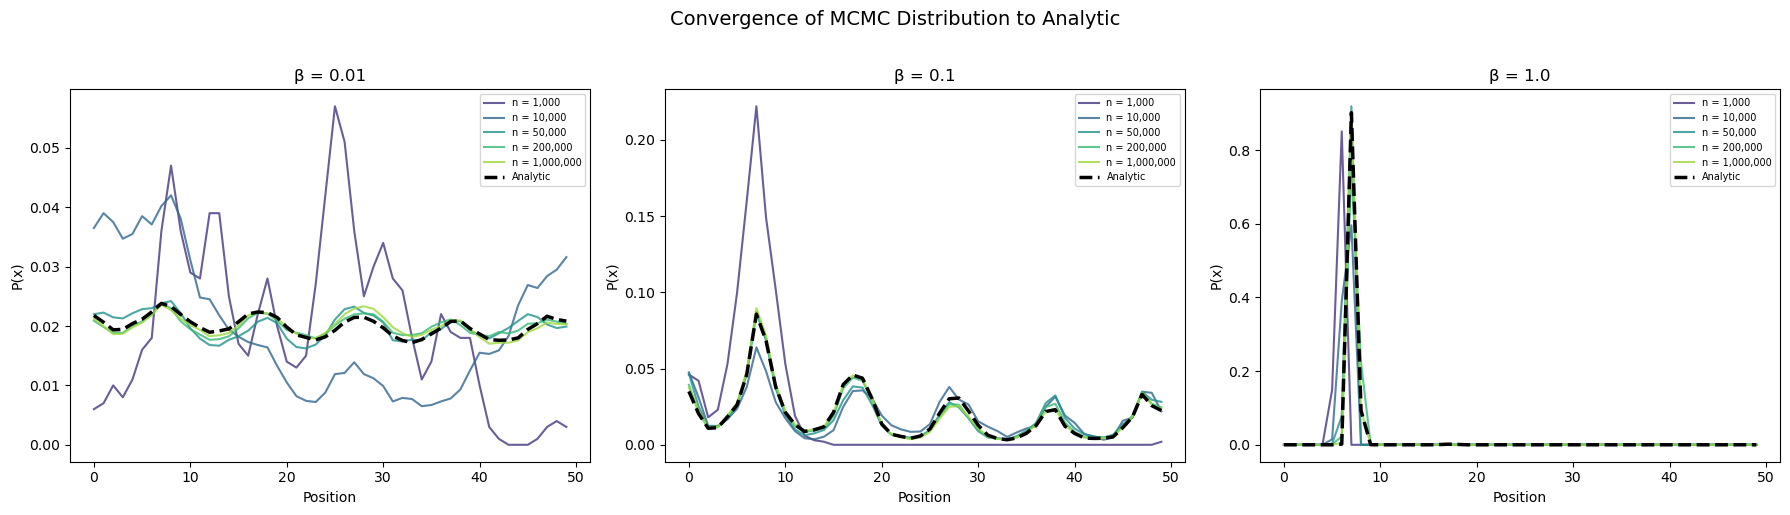

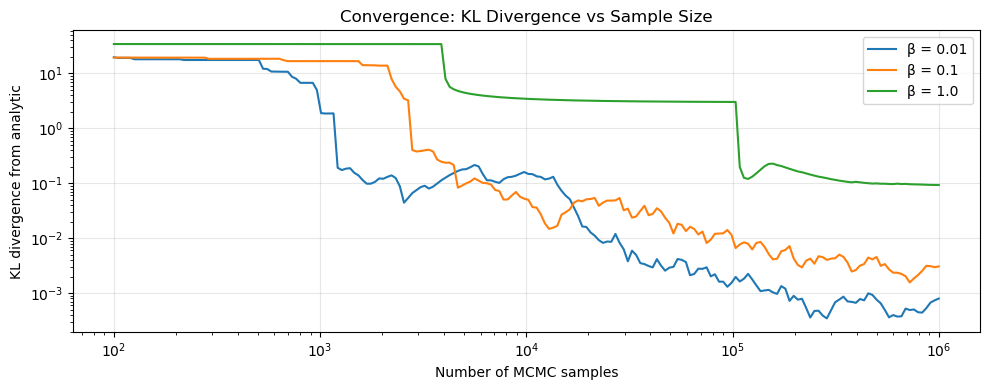

In [21]:
# ---- Convergence plots ----
# Show how the MCMC distribution evolves with increasing number of samples
# compared to the analytic Boltzmann distribution

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
checkpoints = [1_000, 10_000, 50_000, 200_000, 1_000_000]
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(checkpoints)))

for ax, beta in zip(axes, betas):
    chain = results[beta]['chain']
    P_analytic = analytic_distribution(valley_V, beta)
    
    for cp, color in zip(checkpoints, colors):
        counts = np.bincount(chain[:cp], minlength=N) / cp
        ax.plot(valley_pos, counts, '-', color=color, alpha=0.8, label=f'n = {cp:,}')
    
    ax.plot(valley_pos, P_analytic, 'k--', linewidth=2.5, label='Analytic')
    ax.set_title(f'β = {beta}')
    ax.set_xlabel('Position')
    ax.set_ylabel('P(x)')
    ax.legend(fontsize=7, loc='upper right')

plt.suptitle('Convergence of MCMC Distribution to Analytic', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ---- Trace plot of KL divergence vs iteration ----
fig, ax = plt.subplots(figsize=(10, 4))
eval_points = np.logspace(2, np.log10(n_steps), 200).astype(int)

for beta in betas:
    chain = results[beta]['chain']
    P_analytic = analytic_distribution(valley_V, beta)
    kl_divs = []
    
    for n in eval_points:
        P_mcmc = np.bincount(chain[:n], minlength=N) / n
        # KL divergence (avoid log(0) by adding small epsilon)
        P_mcmc_safe = np.clip(P_mcmc, 1e-15, None)
        kl = np.sum(P_analytic * np.log(P_analytic / P_mcmc_safe))
        kl_divs.append(kl)
    
    ax.plot(eval_points, kl_divs, label=f'β = {beta}')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Number of MCMC samples')
ax.set_ylabel('KL divergence from analytic')
ax.set_title('Convergence: KL Divergence vs Sample Size')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Convergence Discussion

- **β = 0.01** (high temperature): The Boltzmann distribution is nearly flat — all positions have roughly equal probability. The acceptance rate is very high (~1), so the chain mixes rapidly and converges quickly. Every proposal is essentially accepted.

- **β = 0.1** (moderate temperature): The distribution shows structure matching the potential landscape. The acceptance rate is lower but still reasonable. The chain explores the landscape well and converges within ~50k samples.

- **β = 1.0** (low temperature): The distribution is sharply peaked at the global minimum of V(x). The acceptance rate is much lower because uphill moves are rarely accepted. The chain can get trapped in local minima and may need many more iterations to fully explore. **Validity of the Markov chain** requires convergence to the target distribution — for β = 1. the chain needs a long burn-in and sufficient samples due to slow mixing across energy barriers.

**Validity conditions for the Markov chain:**
1. **Ergodicity**: The chain must be able to reach any state from any other state. With periodic boundaries and unit steps, this is satisfied.
2. **Detailed balance**: The Metropolis acceptance criterion guarantees this.
3. **Sufficient burn-in**: We must discard early samples before the chain reaches stationarity. For large β this is critical.
4. **Sufficient samples**: The chain must run long enough after burn-in to accurately estimate the distribution.

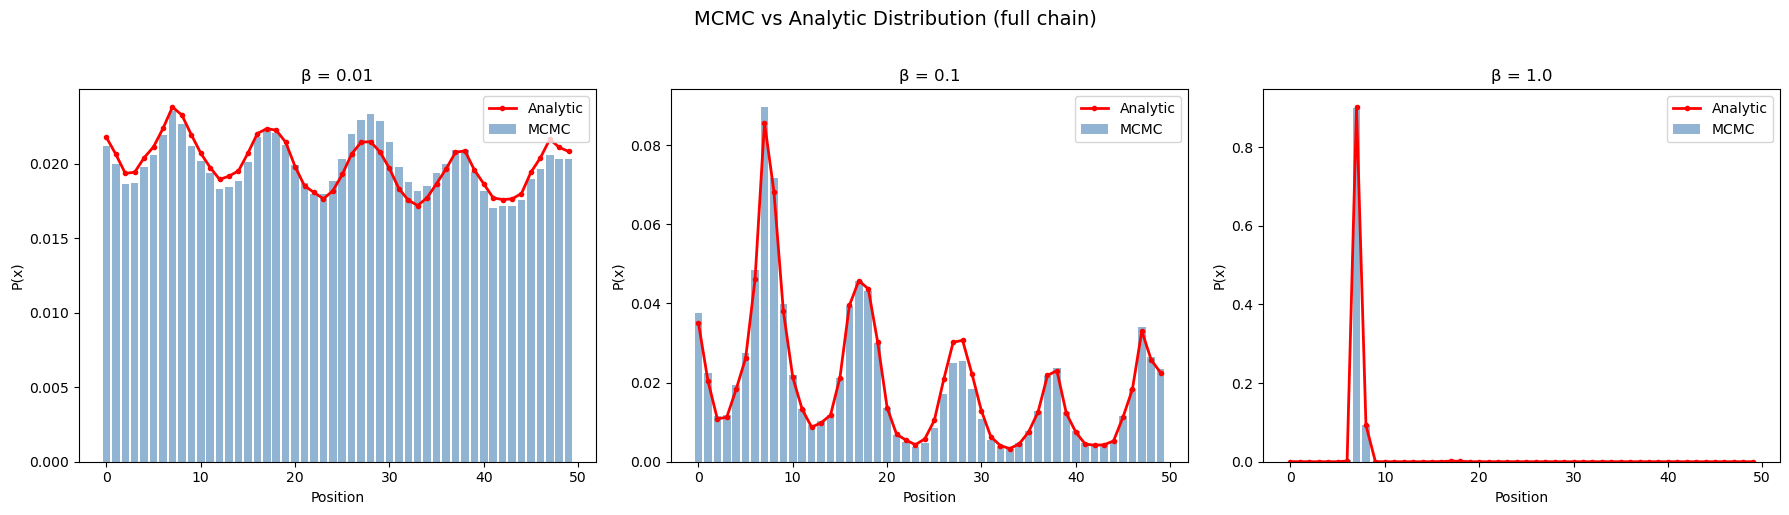

β = 0.01: Σ(P_mcmc - P_analytic)² / P_analytic = 1.64e-03
β = 0.10: Σ(P_mcmc - P_analytic)² / P_analytic = 5.62e-03
β = 1.00: Σ(P_mcmc - P_analytic)² / P_analytic = 1.28e-02


In [22]:
# ---- Compare MCMC with analytic estimate ----
# Analytic: P(x+1)/P(x) = exp(-DeltaV * beta), then normalise.
# This is equivalent to P(x) ∝ exp(-V(x)*beta).

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, beta in zip(axes, betas):
    chain = results[beta]['chain']
    P_mcmc = np.bincount(chain, minlength=N) / len(chain)
    P_analytic = analytic_distribution(valley_V, beta)
    
    ax.bar(valley_pos, P_mcmc, alpha=0.6, color='steelblue', width=0.8, label='MCMC')
    ax.plot(valley_pos, P_analytic, 'r-o', markersize=3, linewidth=2, label='Analytic')
    ax.set_title(f'β = {beta}')
    ax.set_xlabel('Position')
    ax.set_ylabel('P(x)')
    ax.legend()

plt.suptitle('MCMC vs Analytic Distribution (full chain)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Print chi-squared-like comparison
for beta in betas:
    chain = results[beta]['chain']
    P_mcmc = np.bincount(chain, minlength=N) / len(chain)
    P_analytic = analytic_distribution(valley_V, beta)
    residual = np.sum((P_mcmc - P_analytic)**2 / P_analytic)
    print(f"β = {beta:.2f}: Σ(P_mcmc - P_analytic)² / P_analytic = {residual:.2e}")

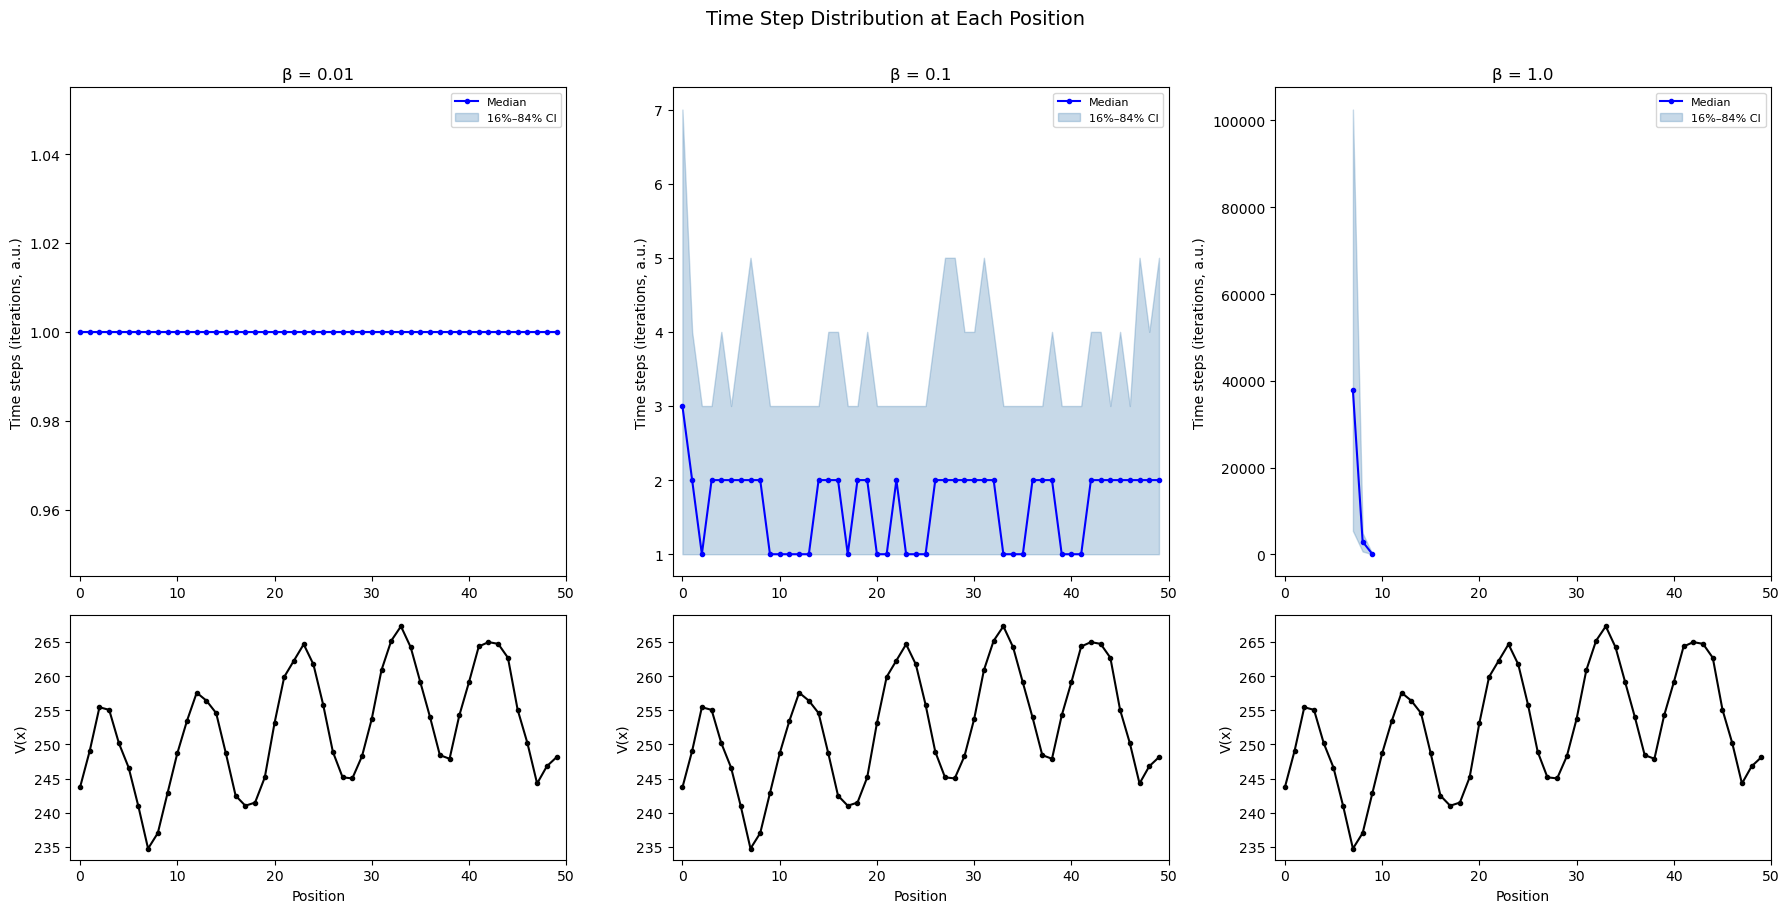

In [23]:
# ---- Time step distribution for different positions ----
# Time step = number of MCMC iterations before the nucleosome moves away from a position.
# Show median and 16%-84% confidence interval for each position and each beta.

fig, axes = plt.subplots(2, 3, figsize=(18, 9), gridspec_kw={'height_ratios': [2, 1]})

for col, beta in enumerate(betas):
    tsteps = results[beta]['time_steps']
    ax = axes[0, col]
    ax_V = axes[1, col]
    
    pos_list = []
    medians = []
    ci_low = []
    ci_high = []
    
    for pos in range(N):
        data = tsteps[pos]
        if len(data) > 5:  # need enough samples
            pos_list.append(pos)
            arr = np.array(data)
            medians.append(np.median(arr))
            ci_low.append(np.percentile(arr, 16))
            ci_high.append(np.percentile(arr, 84))
    
    pos_list = np.array(pos_list)
    medians = np.array(medians)
    ci_low = np.array(ci_low)
    ci_high = np.array(ci_high)
    
    ax.plot(pos_list, medians, 'b-o', markersize=3, label='Median')
    ax.fill_between(pos_list, ci_low, ci_high, alpha=0.3, color='steelblue', label='16%–84% CI')
    ax.set_title(f'β = {beta}')
    ax.set_ylabel('Time steps (iterations, a.u.)')
    ax.legend(fontsize=8)
    ax.set_xlim(-1, N)
    
    # Potential landscape below
    ax_V.plot(valley_pos, valley_V, 'k-o', markersize=3)
    ax_V.set_xlabel('Position')
    ax_V.set_ylabel('V(x)')
    ax_V.set_xlim(-1, N)

axes[0, 0].set_ylabel('Time steps (iterations, a.u.)')
axes[1, 0].set_ylabel('V(x)')
plt.suptitle('Time Step Distribution at Each Position', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Problem 4b — Remodeller Extension

We introduce a **remodeller** protein that can attach to the nucleosome. Properties:
- Attaches and detaches as an exponential process with rate $\tau$
- When attached, it selects a direction (left or right with equal probability) and forces the nucleosome to only attempt moves in that direction until it detaches
- We use $\beta = 0.25$

**Rate $\tau$**: We want 25 nucleosome steps on average before the remodeller attaches. Since attachment is an exponential process, the probability of attaching at each nucleosome step is $p = 1 - e^{-\tau}$. The expected number of steps before attachment is $1/p = 25$, giving:

$$\tau = -\ln\left(1 - \frac{1}{25}\right) = -\ln\left(\frac{24}{25}\right) \approx 0.0408$$

In [24]:
def metropolis_with_remodeller(valley_V, barrier_right, beta, tau, n_steps=1_000_000, x0=None,
                               remodeller_bias=0.5):
    """
    Metropolis-Hastings MCMC with a remodeller that biases movement direction.
    Uses barrier-based acceptance (nucleosome must cross half-integer barrier).
    
    The remodeller:
      - Attaches/detaches with probability p = 1 - exp(-tau) per nucleosome step
      - When attached, chooses left or right (with prob remodeller_bias for right)
        and forces all proposals in that direction
      - When detached, proposals are left/right with equal probability
    
    Parameters:
        remodeller_bias: P(choose right) when remodeller attaches. 0.5 = unbiased.
    """
    N = len(valley_V)
    if x0 is None:
        x0 = np.random.randint(N)
    
    chain = np.zeros(n_steps, dtype=int)
    chain[0] = x0
    
    p_event = 1 - np.exp(-tau)  # probability of remodeller state change per nucleosome step
    remodeller_attached = False
    remodeller_direction = 0  # +1 = right, -1 = left
    
    for i in range(1, n_steps):
        x = chain[i - 1]
        
        if remodeller_attached:
            # Forced direction
            direction = remodeller_direction
        else:
            # Normal: propose left or right
            direction = 1 if np.random.random() < 0.5 else -1
        
        x_prop = (x + direction) % N
        
        # Barrier-based acceptance: must overcome the half-integer barrier
        if direction == 1:
            V_barrier = barrier_right[x]  # barrier at x + 0.5
        else:
            V_barrier = barrier_right[(x - 1) % N]  # barrier at x - 0.5
        
        delta_V = V_barrier - valley_V[x]
        if delta_V <= 0:
            accept = True
        else:
            accept = np.random.random() < np.exp(-delta_V * beta)
        
        if accept:
            chain[i] = x_prop
            # Check remodeller state change after each nucleosome step
            if np.random.random() < p_event:
                if remodeller_attached:
                    remodeller_attached = False
                else:
                    remodeller_attached = True
                    remodeller_direction = 1 if np.random.random() < remodeller_bias else -1
        else:
            chain[i] = x
    
    return chain


# Parameters
beta_4b = 0.25
tau = -np.log(1 - 1/25)  # approx 0.0408
print(f"tau = {tau:.6f}")
print(f"P(state change per step) = {1 - np.exp(-tau):.4f}")
print(f"Expected nucleosome steps between remodeller events = {1 / (1 - np.exp(-tau)):.1f}")

tau = 0.040822
P(state change per step) = 0.0400
Expected nucleosome steps between remodeller events = 25.0


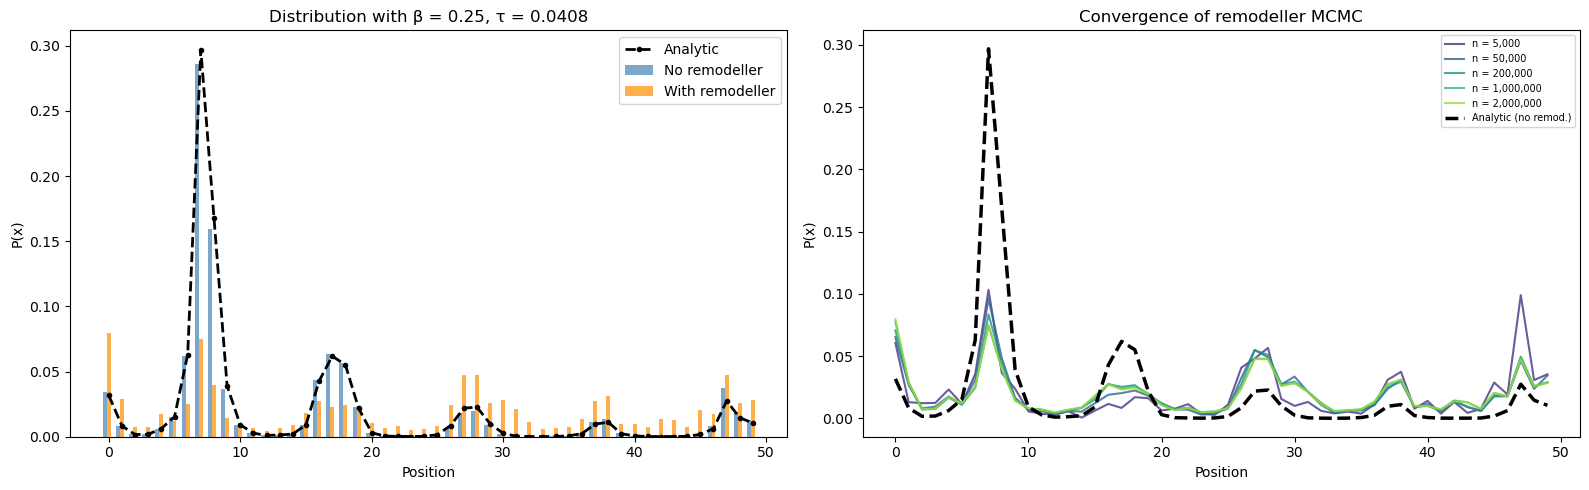

Acceptance rate (no remodeller): 0.1156
Acceptance rate (with remodeller): 0.1031


In [25]:
# ---- Run with and without remodeller for β = 0.25 ----
n_steps_4b = 2_000_000

# Without remodeller
chain_no_remod, _ = metropolis_nucleosome(valley_V, barrier_right, beta_4b, n_steps=n_steps_4b)

# With remodeller (unbiased, τ ≈ 0.04)
chain_with_remod = metropolis_with_remodeller(valley_V, barrier_right, beta_4b, tau, n_steps=n_steps_4b)

# Analytic (no remodeller)
P_analytic_4b = analytic_distribution(valley_V, beta_4b)

# Compare distributions
P_no_remod = np.bincount(chain_no_remod, minlength=N) / len(chain_no_remod)
P_with_remod = np.bincount(chain_with_remod, minlength=N) / len(chain_with_remod)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribution comparison
ax = axes[0]
ax.bar(valley_pos - 0.3, P_no_remod, width=0.3, alpha=0.7, color='steelblue', label='No remodeller')
ax.bar(valley_pos, P_with_remod, width=0.3, alpha=0.7, color='darkorange', label='With remodeller')
ax.plot(valley_pos, P_analytic_4b, 'k--o', markersize=3, linewidth=2, label='Analytic')
ax.set_xlabel('Position')
ax.set_ylabel('P(x)')
ax.set_title(f'Distribution with β = {beta_4b}, τ = {tau:.4f}')
ax.legend()

# Convergence check
ax = axes[1]
checkpoints = [5_000, 50_000, 200_000, 1_000_000, 2_000_000]
colors_cp = plt.cm.viridis(np.linspace(0.15, 0.85, len(checkpoints)))
for cp, color in zip(checkpoints, colors_cp):
    counts = np.bincount(chain_with_remod[:cp], minlength=N) / cp
    ax.plot(valley_pos, counts, '-', color=color, alpha=0.8, label=f'n = {cp:,}')
ax.plot(valley_pos, P_analytic_4b, 'k--', linewidth=2.5, label='Analytic (no remod.)')
ax.set_xlabel('Position')
ax.set_ylabel('P(x)')
ax.set_title('Convergence of remodeller MCMC')
ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

print(f"Acceptance rate (no remodeller): {np.mean(np.diff(chain_no_remod) != 0):.4f}")
print(f"Acceptance rate (with remodeller): {np.mean(np.diff(chain_with_remod) != 0):.4f}")

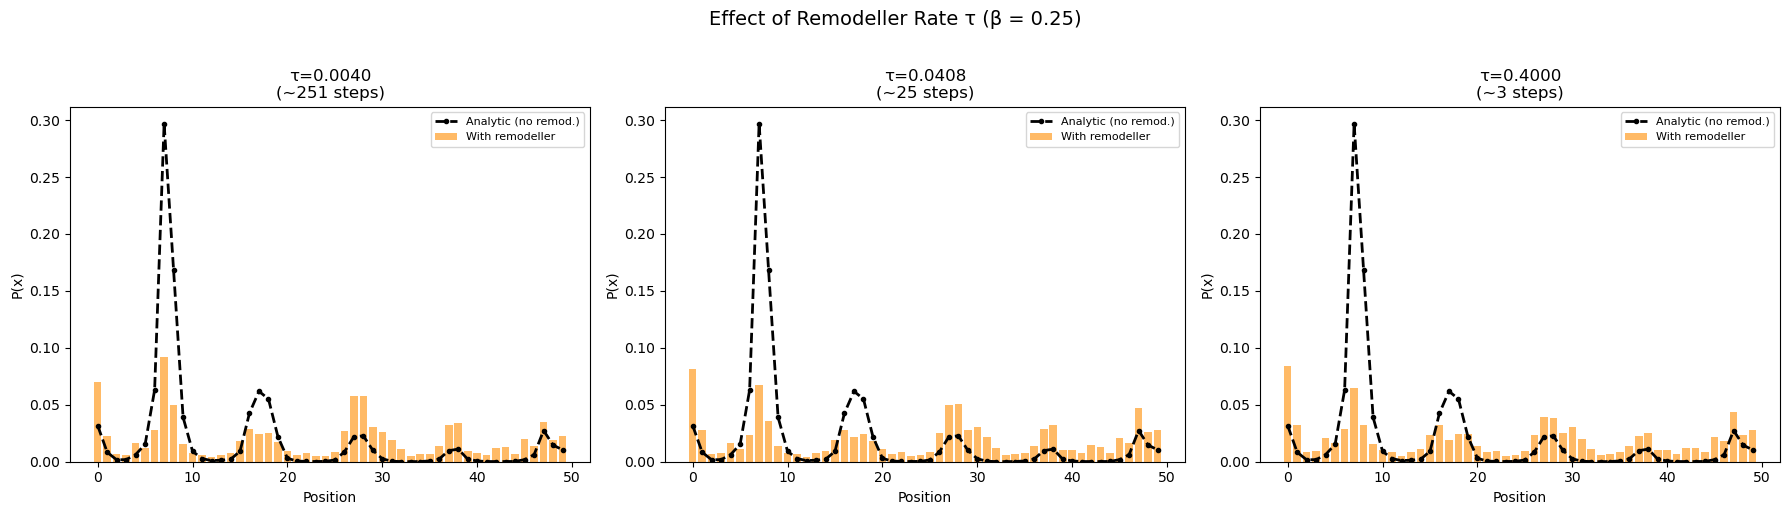

In [26]:
# ---- Effect of changing τ ----
# Compare different remodeller rates: faster (more frequent) and slower (less frequent)

tau_values = [0.004, tau, 0.4]  # slow (250 steps), default (25 steps), fast (2.5 steps)
tau_labels = [f'τ={t:.4f}\n(~{1/(1-np.exp(-t)):.0f} steps)' for t in tau_values]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, t, label in zip(axes, tau_values, tau_labels):
    chain_t = metropolis_with_remodeller(valley_V, barrier_right, beta_4b, t, n_steps=n_steps_4b)
    P_t = np.bincount(chain_t, minlength=N) / len(chain_t)
    
    ax.bar(valley_pos, P_t, alpha=0.6, color='darkorange', width=0.8, label='With remodeller')
    ax.plot(valley_pos, P_analytic_4b, 'k--o', markersize=3, linewidth=2, label='Analytic (no remod.)')
    ax.set_title(label)
    ax.set_xlabel('Position')
    ax.set_ylabel('P(x)')
    ax.legend(fontsize=8)

plt.suptitle(f'Effect of Remodeller Rate τ (β = {beta_4b})', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

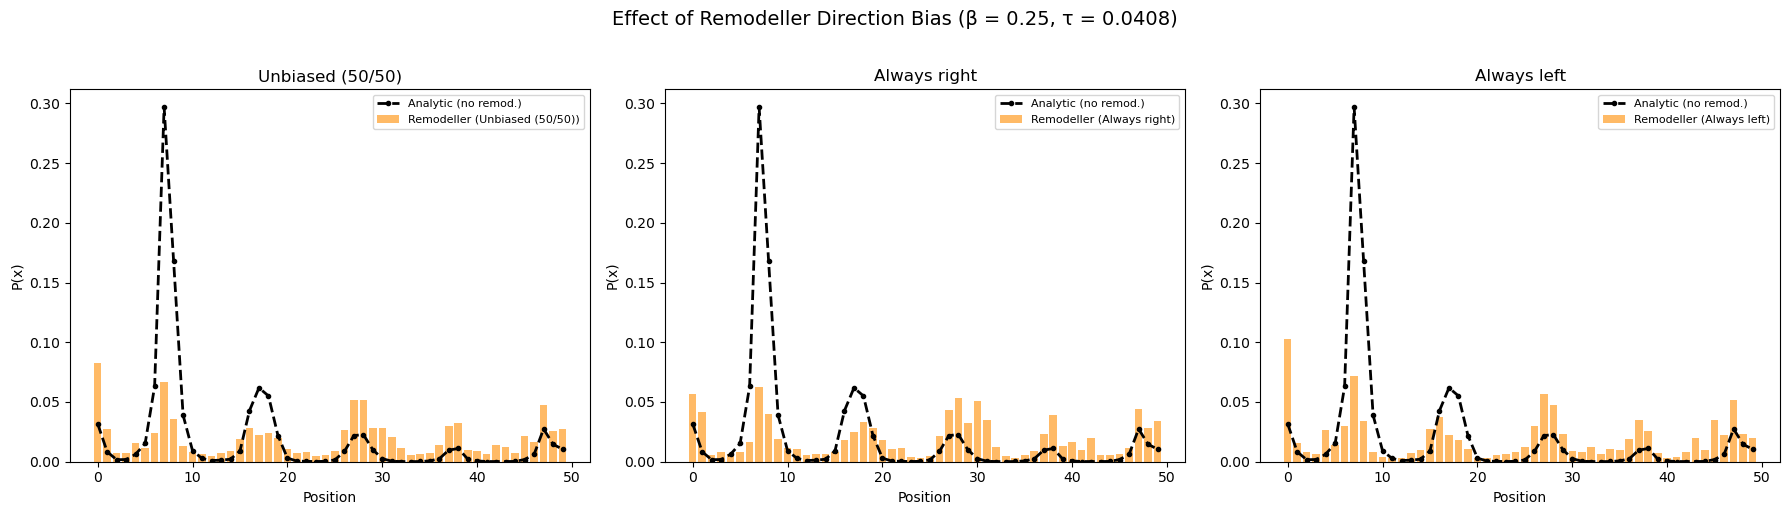

In [27]:
# ---- Effect of biased remodeller direction ----
# Compare: unbiased (50/50), always right, always left

bias_configs = [
    (0.5, 'Unbiased (50/50)'),
    (1.0, 'Always right'),
    (0.0, 'Always left'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (bias, label) in zip(axes, bias_configs):
    chain_b = metropolis_with_remodeller(valley_V, barrier_right, beta_4b, tau, n_steps=n_steps_4b,
                                          remodeller_bias=bias)
    P_b = np.bincount(chain_b, minlength=N) / len(chain_b)
    
    ax.bar(valley_pos, P_b, alpha=0.6, color='darkorange', width=0.8, label=f'Remodeller ({label})')
    ax.plot(valley_pos, P_analytic_4b, 'k--o', markersize=3, linewidth=2, label='Analytic (no remod.)')
    ax.set_title(label)
    ax.set_xlabel('Position')
    ax.set_ylabel('P(x)')
    ax.legend(fontsize=8)

plt.suptitle(f'Effect of Remodeller Direction Bias (β = {beta_4b}, τ = {tau:.4f})', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Problem 4b Discussion

**Effect of remodeller (unbiased, τ ≈ 0.04):**
With an unbiased remodeller (50/50 left/right), the equilibrium distribution remains close to the Boltzmann distribution $P(x) \propto e^{-V(x)\beta}$. This is because the directional bias averages out: when the remodeller forces right as often as left, the net effect on the stationary distribution is small. However, the **dynamics** change — the nucleosome may traverse barriers more efficiently when forced in one direction, potentially improving mixing.

**Effect of changing τ:**
- **Small τ** (rare remodeller events): The remodeller attaches/detaches infrequently, so the system behaves mostly like standard Metropolis. The distribution is close to Boltzmann.
- **Large τ** (frequent remodeller events): The remodeller switches on/off rapidly. When attached, the nucleosome is forced in one direction for only a few steps before the remodeller detaches. With an unbiased remodeller, the distribution still approximates Boltzmann, but the dynamics are more "jerky".

**Effect of biased remodeller direction:**
When the remodeller is heavily biased (e.g., always to the right), detailed balance is **broken**. The nucleosome experiences a systematic drift in one direction around the periodic landscape. This creates a non-equilibrium steady state where the distribution deviates from the Boltzmann equilibrium. Positions that are "downhill" in the forced direction become more populated, while positions requiring uphill moves in the forced direction become depleted. The distribution shifts noticeably from the analytic result, confirming that the directional bias introduces a non-equilibrium current through the system.

## Continuous Metropolis — Cubic Spline Interpolation

Instead of restricting the nucleosome to integer positions, we interpolate the full potential landscape (valleys + barriers) with a periodic cubic spline. The nucleosome position $x$ is now a continuous real variable in $[0, 50)$, and proposals are Gaussian perturbations $x' = x + \mathcal{N}(0, \sigma^2)$ with periodic wrapping.

The acceptance criterion is the standard Metropolis ratio:
$$\alpha = \min\!\left(1,\; e^{-\beta\left[V(x') - V(x)\right]}\right)$$

No separate barrier logic is needed — the barriers are naturally encoded in the continuous $V(x)$. The proposal width $\sigma$ controls exploration efficiency.

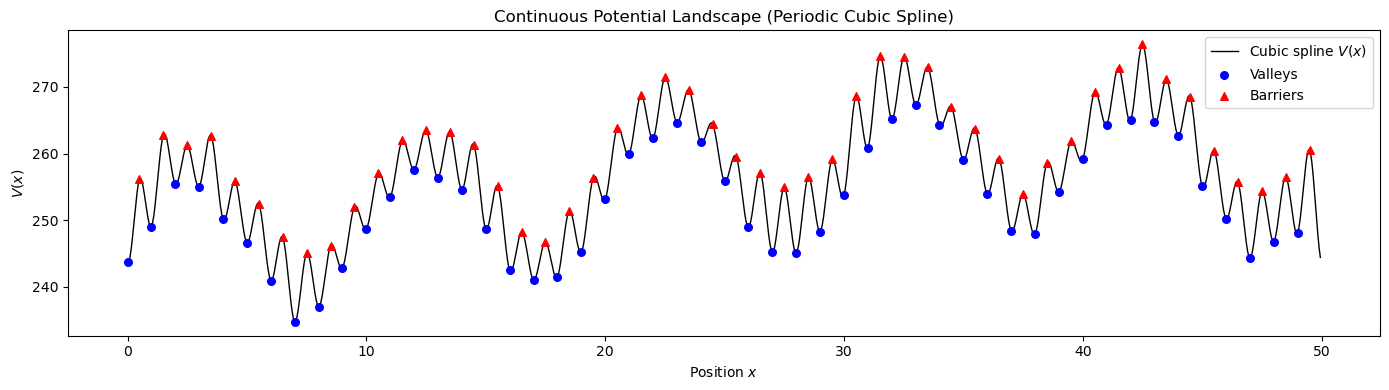

Spline built. V(0) = 243.701, V(50) = 243.701 (periodic check)


In [28]:
from scipy.interpolate import CubicSpline

# Build periodic cubic spline through ALL 100 data points
# The landscape is periodic with period L=50
L = 50.0

# scipy CubicSpline with bc_type='periodic' needs f(0) == f(L)
# Our data goes from x=0 to x=49.5, so we append x=50 with V(50)=V(0) for periodicity
positions_ext = np.append(positions, L)
potentials_ext = np.append(potentials, potentials[0])  # V(50) = V(0)

V_spline = CubicSpline(positions_ext, potentials_ext, bc_type='periodic')

# Plot the spline vs data
x_fine = np.linspace(0, L, 1000, endpoint=False)
V_fine = V_spline(x_fine)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(x_fine, V_fine, 'k-', lw=1, label='Cubic spline $V(x)$')
ax.scatter(valley_pos, valley_V, c='blue', s=30, zorder=5, label='Valleys')
ax.scatter(barrier_pos, barrier_V_raw, c='red', marker='^', s=30, zorder=5, label='Barriers')
ax.set_xlabel('Position $x$')
ax.set_ylabel('$V(x)$')
ax.set_title('Continuous Potential Landscape (Periodic Cubic Spline)')
ax.legend()
plt.tight_layout()
plt.show()


def metropolis_continuous(V_func, L, beta, sigma=0.5, n_steps=1_000_000, x0=None):
    """
    Continuous Metropolis MCMC on a periodic potential V(x), x in [0, L).
    Proposals: x' = (x + N(0, sigma^2)) mod L  (Gaussian with periodic wrapping)
    Acceptance: min(1, exp(-beta * (V(x') - V(x))))
    """
    if x0 is None:
        x0 = np.random.uniform(0, L)
    
    chain = np.zeros(n_steps)
    chain[0] = x0
    n_accept = 0
    
    for i in range(1, n_steps):
        x = chain[i - 1]
        x_prop = (x + np.random.normal(0, sigma)) % L
        
        dV = V_func(x_prop) - V_func(x)
        if dV <= 0 or np.random.random() < np.exp(-beta * dV):
            chain[i] = x_prop
            n_accept += 1
        else:
            chain[i] = x
    
    acceptance_rate = n_accept / (n_steps - 1)
    return chain, acceptance_rate


def analytic_continuous(V_func, L, beta, n_bins=200):
    """
    Analytic (numerical) target distribution: P(x) proportional to exp(-beta*V(x)),
    evaluated on a fine grid and normalised as a histogram-compatible density.
    """
    x_grid = np.linspace(0, L, n_bins + 1)
    x_mid = 0.5 * (x_grid[:-1] + x_grid[1:])
    dx = x_grid[1] - x_grid[0]
    
    P = np.exp(-beta * V_func(x_mid))
    P /= (P.sum() * dx)  # normalise so integral ≈ 1
    return x_mid, P


print("Spline built. V(0) = {:.3f}, V(50) = {:.3f} (periodic check)".format(
    V_spline(0.0), V_spline(L)))

In [29]:
np.random.seed(42)

betas_cont = [0.01, 0.1, 1.0]
sigma = 0.5  # proposal width
n_steps_cont = 2_000_000
results_cont = {}

for b in betas_cont:
    chain_c, acc_c = metropolis_continuous(V_spline, L, b, sigma=sigma, n_steps=n_steps_cont)
    results_cont[b] = (chain_c, acc_c)
    print(f"β = {b:.2f}: acceptance rate = {acc_c:.4f}")

β = 0.01: acceptance rate = 0.9815
β = 0.10: acceptance rate = 0.8167
β = 1.00: acceptance rate = 0.1714


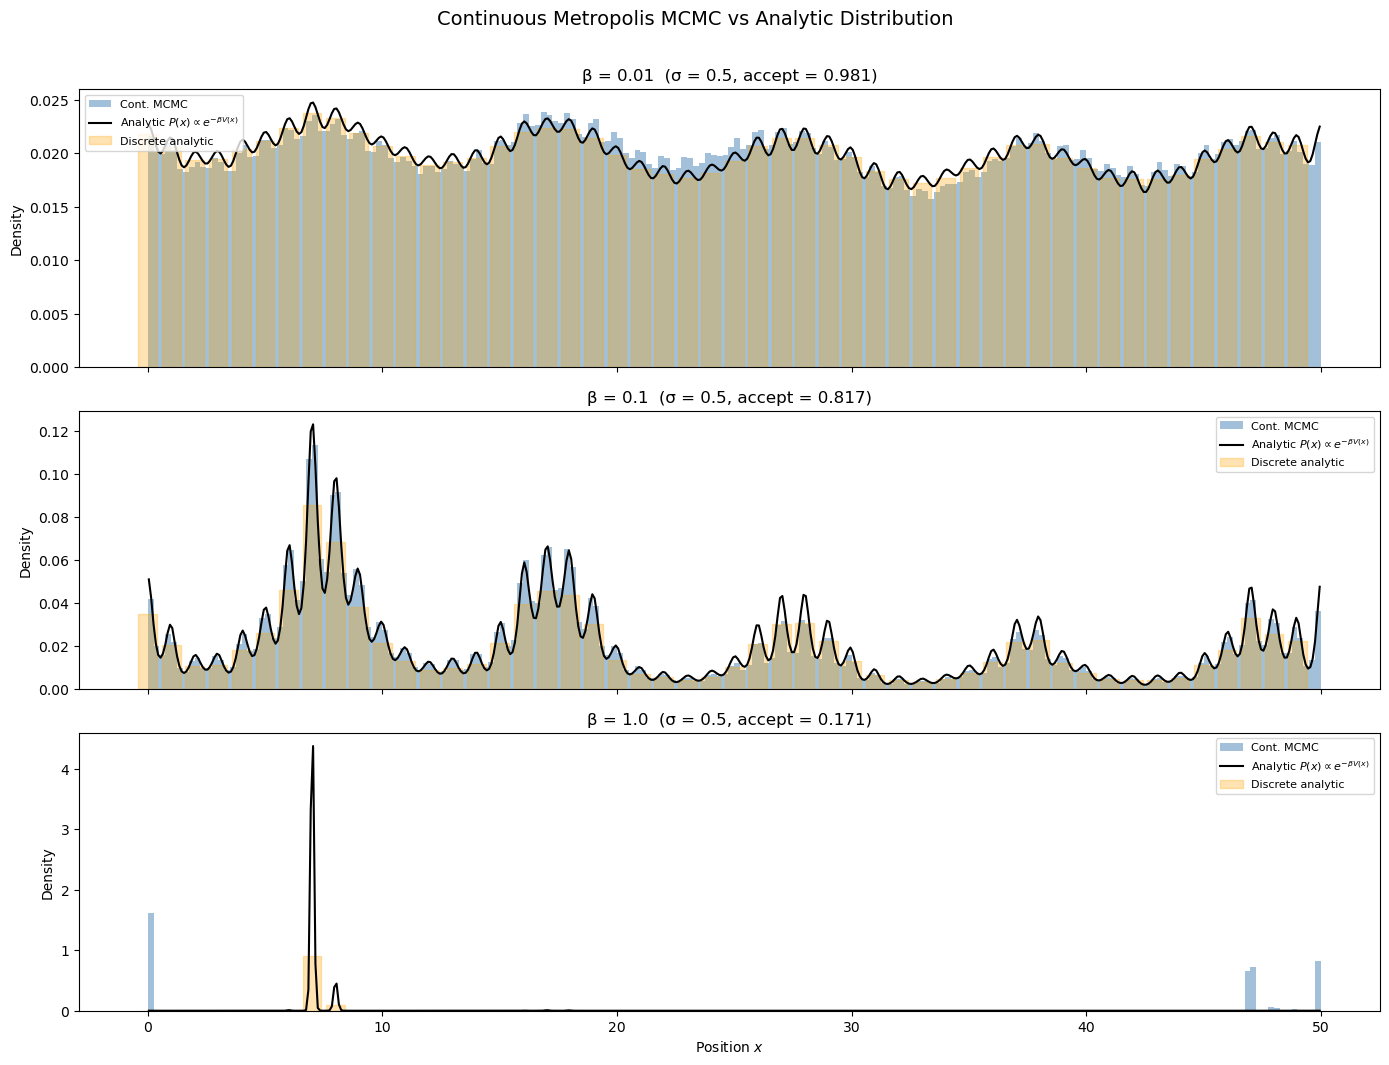

In [30]:
n_bins = 200
burn_in = 10_000

fig, axes = plt.subplots(len(betas_cont), 1, figsize=(14, 3.5 * len(betas_cont)), sharex=True)

for idx, b in enumerate(betas_cont):
    ax = axes[idx]
    chain_c = results_cont[b][0][burn_in:]
    
    # MCMC histogram (density)
    ax.hist(chain_c, bins=n_bins, range=(0, L), density=True, alpha=0.5, color='steelblue', label='Cont. MCMC')
    
    # Analytic continuous density
    x_mid, P_analytic_c = analytic_continuous(V_spline, L, b, n_bins=500)
    ax.plot(x_mid, P_analytic_c, 'k-', lw=1.5, label=r'Analytic $P(x) \propto e^{-\beta V(x)}$')
    
    # Overlay discrete analytic as bars (rescaled to density: each bar covers width=1)
    P_disc = analytic_distribution(valley_V, b)
    ax.bar(valley_pos, P_disc, width=0.8, alpha=0.3, color='orange', edgecolor='orange',
           label='Discrete analytic')
    
    ax.set_ylabel('Density')
    ax.set_title(f'β = {b}  (σ = {sigma}, accept = {results_cont[b][1]:.3f})')
    ax.legend(fontsize=8)

axes[-1].set_xlabel('Position $x$')
plt.suptitle('Continuous Metropolis MCMC vs Analytic Distribution', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

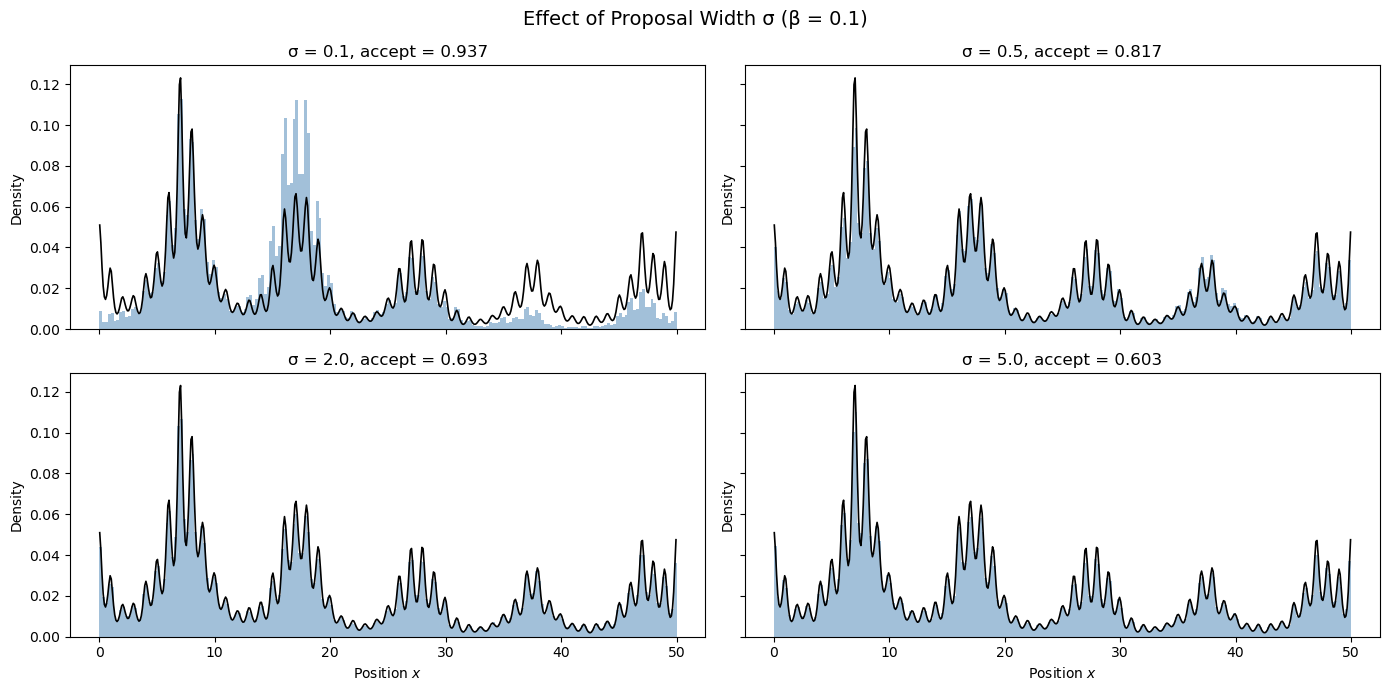

In [31]:
# Effect of proposal width sigma at beta=0.1
np.random.seed(42)
sigmas = [0.1, 0.5, 2.0, 5.0]
beta_test = 0.1
n_steps_sigma = 1_000_000

fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True, sharey=True)
x_mid, P_target = analytic_continuous(V_spline, L, beta_test, n_bins=500)

for ax, sig in zip(axes.flat, sigmas):
    chain_s, acc_s = metropolis_continuous(V_spline, L, beta_test, sigma=sig, n_steps=n_steps_sigma)
    chain_s = chain_s[5000:]  # burn-in
    
    ax.hist(chain_s, bins=200, range=(0, L), density=True, alpha=0.5, color='steelblue')
    ax.plot(x_mid, P_target, 'k-', lw=1.2)
    ax.set_title(f'σ = {sig}, accept = {acc_s:.3f}')
    ax.set_ylabel('Density')

axes[1, 0].set_xlabel('Position $x$')
axes[1, 1].set_xlabel('Position $x$')
plt.suptitle(f'Effect of Proposal Width σ (β = {beta_test})', fontsize=14)
plt.tight_layout()
plt.show()